# Notebook 01 — SCLC causal discovery

Single-class KG (`SCLC_patients.ttl`): 1 class, 10 data properties, 0 object properties.
It is a **correctness / regression** dataset — because the topological constraint is vacuous here, **constrained and unconstrained runs must produce identical graphs**. The synthetic 3-class KG (notebook 02) is what actually exercises the pruning.

In [1]:
import os, sys

def _find_root():
    p = os.getcwd()
    for _ in range(8):
        if os.path.isdir(os.path.join(p, 'causalway')) and os.path.isdir(os.path.join(p, 'algs')):
            return p
        p = os.path.dirname(p)
    raise RuntimeError('project root not found')

PROJECT_ROOT = _find_root()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import rdflib, pandas, numpy, networkx, pgmpy, castle, torch
print('rdflib', rdflib.__version__, '| pandas', pandas.__version__, '| numpy', numpy.__version__)
import dagma
print('dagma OK')
print('PROJECT_ROOT =', PROJECT_ROOT)

rdflib 7.6.0 | pandas 3.0.1 | numpy 2.4.3
dagma OK
PROJECT_ROOT = /Users/jason/Documents/Coding Projects.nosync/2026_Claude/CausalKG_api


In [2]:
from causalway.ontology import OntologySchema
import pandas as pd

schema = OntologySchema.from_file(os.path.join(PROJECT_ROOT, 'kgs', 'ttls', 'SCLC_patients.ttl'))
pd.DataFrame([schema.summary()]).T

,0
n_classes,1
n_object_properties,0
n_object_domain_range,0
n_data_properties,10
n_data_domain_range,10
n_inferred,0


In [3]:
from causalway.nodes import build_nodes

nodes = build_nodes(schema)
for n in nodes:
    print(n.name.ljust(28), 'kind=' + n.kind.ljust(5), 'domain=' + n.var)
print('total nodes:', len(nodes))

SCLCPatient.ageGroup         kind=data  domain=SCLCPatient
SCLCPatient.biomarker        kind=data  domain=SCLCPatient
SCLCPatient.episodeType      kind=data  domain=SCLCPatient
SCLCPatient.familyCancer     kind=data  domain=SCLCPatient
SCLCPatient.familyGender     kind=data  domain=SCLCPatient
SCLCPatient.gender           kind=data  domain=SCLCPatient
SCLCPatient.locatedIn        kind=data  domain=SCLCPatient
SCLCPatient.relapseStatus    kind=data  domain=SCLCPatient
SCLCPatient.smokerType       kind=data  domain=SCLCPatient
SCLCPatient.stage            kind=data  domain=SCLCPatient
total nodes: 10


{'n_nodes': 10, 'n_allowed': 90, 'n_forbidden': 0, 'pruning_rate': 0.0}


<Axes: title={'center': 'Allowed edges (Assumption 1)'}>

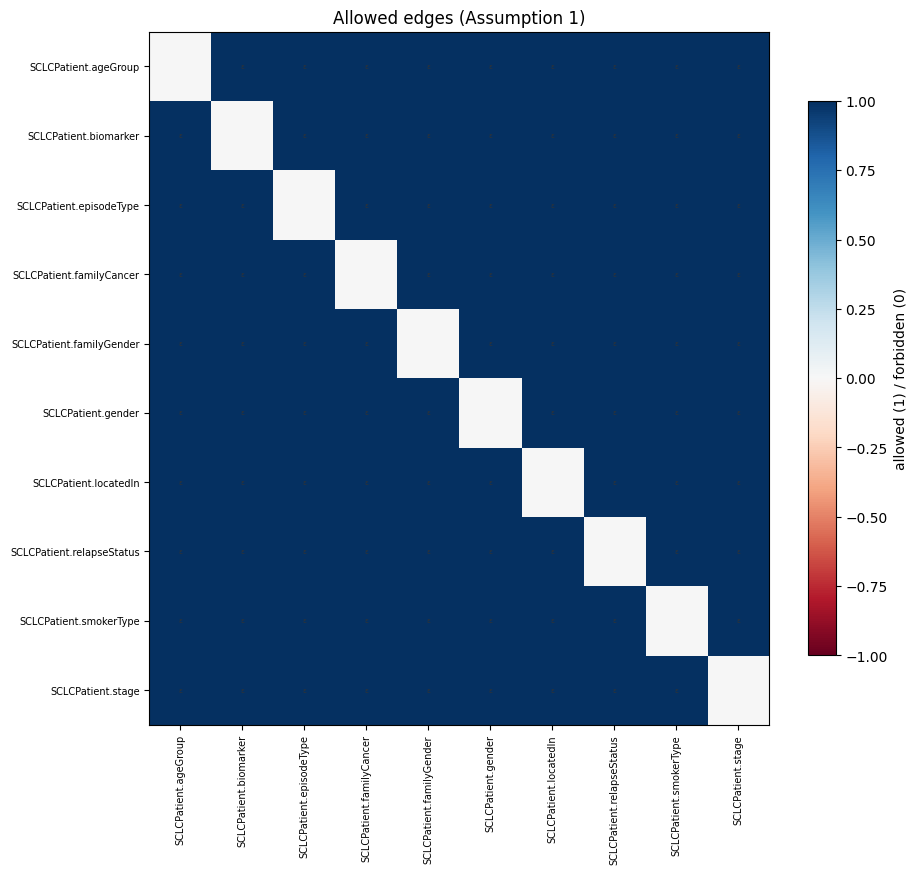

In [4]:
from causalway.constraints import EdgeConstraint
from causalway.plotting import plot_constraint_heatmap

constraint = EdgeConstraint.from_schema(schema, nodes)
print(constraint.stats())
# Expected: pruning_rate == 0.0  (one class, no object properties)
plot_constraint_heatmap(constraint)

In [5]:
from runners.run_sclc import build_sclc_context, verify_matches_csv

ctx = build_sclc_context()
print('rows x cols:', ctx.mat.df.shape)
print('SPARQL:\n', ctx.mat.query)
assert verify_matches_csv(ctx)
print('materialization matches kgs/csvs/SCLC_patients.csv ✓')

2026-09-23 09:50:29,313 - /Users/jason/miniconda3/envs/rdfenv/lib/python3.11/site-packages/castle/backend/__init__.py[line:36] - INFO: You can use `os.environ['CASTLE_BACKEND'] = backend` to set the backend(`pytorch` or `mindspore`).


2026-09-23 09:50:29,450 - /Users/jason/miniconda3/envs/rdfenv/lib/python3.11/site-packages/castle/algorithms/__init__.py[line:36] - INFO: You are using ``pytorch`` as the backend.


/Users/jason/miniconda3/envs/rdfenv/lib/python3.11/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


rows x cols: (4279, 10)
SPARQL:
 SELECT ?SCLCPatient ?SCLCPatient__ageGroup ?SCLCPatient__biomarker ?SCLCPatient__episodeType ?SCLCPatient__familyCancer ?SCLCPatient__familyGender ?SCLCPatient__gender ?SCLCPatient__locatedIn ?SCLCPatient__relapseStatus ?SCLCPatient__smokerType ?SCLCPatient__stage
WHERE {
    ?SCLCPatient a <http://causalkg.example.org/sclc/SCLCPatient> .
    ?SCLCPatient <http://causalkg.example.org/sclc/ageGroup> ?SCLCPatient__ageGroup .
    ?SCLCPatient <http://causalkg.example.org/sclc/biomarker> ?SCLCPatient__biomarker .
    ?SCLCPatient <http://causalkg.example.org/sclc/episodeType> ?SCLCPatient__episodeType .
    ?SCLCPatient <http://causalkg.example.org/sclc/familyCancer> ?SCLCPatient__familyCancer .
    ?SCLCPatient <http://causalkg.example.org/sclc/familyGender> ?SCLCPatient__familyGender .
    ?SCLCPatient <http://causalkg.example.org/sclc/gender> ?SCLCPatient__gender .
    ?SCLCPatient <http://causalkg.example.org/sclc/locatedIn> ?SCLCPatient__locatedIn .
  

In [6]:
from runners.run_kg_discovery import run_algorithm
import numpy as np

methods = ['GES', 'GES-M-B-HL', 'GES-M-B', 'PC', 'NOTEARS', 'DAGMA'] #, 'LiNGAM', 'DAG-GNN']
results = {}
for m in methods:
    c, c_w = run_algorithm(m, ctx, constrained=True, return_weights=True)
    u = run_algorithm(m, ctx, constrained=False)
    results[m] = (c, u, c_w)
    same = np.array_equal(c, u)
    print(m.ljust(12), 'constrained == unconstrained:', same, ' (edges:', int(c.sum()), ')')
    assert same, m + ': vacuous constraint changed the graph'
print('All methods: constraint plumbing is a no-op on a vacuous constraint ✓')

GES          constrained == unconstrained: True  (edges: 15 )


  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

GES-M-B-HL   constrained == unconstrained: True  (edges: 15 )


2026-09-23 09:50:34,123 - /Users/jason/Documents/Coding Projects.nosync/2026_Claude/CausalKG_api/algs/constrained/notears.py[line:105] - INFO: [start]: n=4279, d=10, iter_=100, h_=1e-08, rho_=1e+16


...

2026-09-23 09:50:34,142 - /Users/jason/miniconda3/envs/rdfenv/lib/python3.11/site-packages/castle/algorithms/gradient/notears/linear.py[line:222] - INFO: FINISHED


GES-M-B      constrained == unconstrained: True  (edges: 15 )
PC           constrained == unconstrained: True  (edges: 13 )
NOTEARS      constrained == unconstrained: True  (edges: 0 )


  0%|          | 0/180000.0 [00:00<?, ?it/s]

  0%|          | 0/180000.0 [00:00<?, ?it/s]

DAGMA        constrained == unconstrained: True  (edges: 1 )
All methods: constraint plumbing is a no-op on a vacuous constraint ✓


In [7]:
from runners.run_kg_discovery import estimate_and_cache_priors, run_algorithm

cache = os.path.join(PROJECT_ROOT, 'results', 'priors_sclc.json')
priors, var_meta, pair_meta, domain = estimate_and_cache_priors(ctx, cache, llm_model='deepseek-v4-flash-vision-exp') #'deepseek-v4-flash')
if priors is None:
    print('LLM priors unavailable (check DEEPSEEK_KEY in algs/.env); skipping the LLM-prior run')
else:
    adj = run_algorithm('GES-M-B-HL', ctx, constrained=True,
                        priors=priors, var_meta=var_meta, pair_meta=pair_meta, domain=domain)
    print('GES-M-B-HL (LLM priors) edges:', int(adj.sum()))

Loading cached priors from /Users/jason/Documents/Coding Projects.nosync/2026_Claude/CausalKG_api/results/priors_sclc.json


  0%|          | 0/1000000 [00:00<?, ?it/s]

GES-M-B-HL (LLM priors) edges: 13


GES          -> 15 edges   GES-8e3f4e312e14


GES-M-B-HL   -> 15 edges   GES-M-B-HL-2ca80308aeb9


GES-M-B      -> 15 edges   GES-M-B-ed88bda2ce85


PC           -> 13 edges   PC-454b442f3fa6


NOTEARS      -> 0 edges   NOTEARS-0e3d9c7aefa7


DAGMA        -> 1 edges   DAGMA-d1ad8a8be890


<Axes: title={'center': 'Ontological causal graph'}>

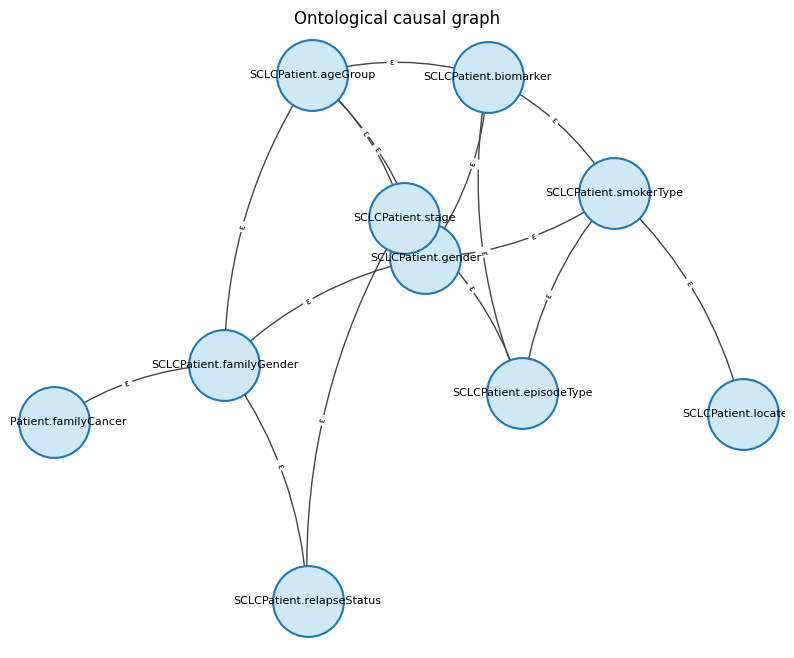

In [8]:
from runners.run_kg_discovery import to_ocg
from causalway.result import write_bundle
from causalway.plotting import plot_graph

out_dir = os.path.join(PROJECT_ROOT, 'results', 'sclc')
os.makedirs(out_dir, exist_ok=True)

ocgs = {}
for m, (c_adj, u_adj, c_w) in results.items():
    ocg = to_ocg(c_adj, ctx, constrained=True, weights=c_w, method=m)
    ocg.to_turtle(os.path.join(out_dir, m + '.ttl'))
    ocgs[m] = ocg
    print(m.ljust(12), '->', len(ocg.to_dataframe()), 'edges  ', ocg.gid)

# 八个方法合成一个 KG 文件，node IRI 全局，可在同一批节点上比较
write_bundle(ocgs, os.path.join(out_dir, 'all_methods.ttl'))

plot_graph(ocgs['GES'])